Load the data set

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
import joblib


Matplotlib is building the font cache; this may take a moment.


In [26]:
import pandas as pd

df = pd.read_csv("models/synthetic_health_risk_dataset_1000.csv")
print(df.head())
print(df.info())


   age  gender  height_m  weight_kg   bmi  activity_level  daily_calories  \
0   56       0      1.61       93.7  36.1               0            2273   
1   46       1      1.73       84.8  28.3               1            2288   
2   32       0      1.47       48.9  22.6               1            1999   
3   60       1      1.84       75.8  22.4               0            2351   
4   25       0      1.89       76.8  21.5               1            3156   

   sugar_g  sodium_mg  fat_g  carbs_g  protein_g  diabetes_risk  \
0       66       3667    130      238        106              1   
1       75       4316     92      216        169              1   
2       18       4167    134      398         84              0   
3      116       2501     39      375         80              0   
4      109       4042     44      376        131              0   

   hypertension_risk  obesity_risk  
0                  1             1  
1                  1             0  
2                  1   

Basic Data Validation

In [27]:
print("\nData Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   gender             1000 non-null   int64  
 2   height_m           1000 non-null   float64
 3   weight_kg          1000 non-null   float64
 4   bmi                1000 non-null   float64
 5   activity_level     1000 non-null   int64  
 6   daily_calories     1000 non-null   int64  
 7   sugar_g            1000 non-null   int64  
 8   sodium_mg          1000 non-null   int64  
 9   fat_g              1000 non-null   int64  
 10  carbs_g            1000 non-null   int64  
 11  protein_g          1000 non-null   int64  
 12  diabetes_risk      1000 non-null   int64  
 13  hypertension_risk  1000 non-null   int64  
 14  obesity_risk       1000 non-null   int64  
dtypes: float64(3), int64(12)
memory usage: 117.3 KB
None

Missing Values:
ag

DATA CLEANING & PREPROCESSING

In [28]:
df.fillna(df.mean(numeric_only=True), inplace=True)


,age,gender,height_m,weight_kg,bmi,activity_level,daily_calories,sugar_g,sodium_mg,fat_g,carbs_g,protein_g,diabetes_risk,hypertension_risk,obesity_risk
0,56,0,1.61,93.7,36.1,0,2273,66,3667,130,238,106,1,1,1
1,46,1,1.73,84.8,28.3,1,2288,75,4316,92,216,169,1,1,0
2,32,0,1.47,48.9,22.6,1,1999,18,4167,134,398,84,0,1,0
3,60,1,1.84,75.8,22.4,0,2351,116,2501,39,375,80,0,1,0
4,25,0,1.89,76.8,21.5,1,3156,109,4042,44,376,131,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23,1,1.79,68.3,21.3,0,2751,78,1691,93,478,87,0,0,0
996,43,1,1.80,106.3,32.8,0,2840,67,1341,65,241,175,1,1,1
997,21,0,1.75,103.1,33.7,0,2711,66,2087,88,143,96,1,1,1
998,36,1,1.57,64.6,26.2,2,2936,71,2433,133,243,151,1,1,0


encode categorical data

In [29]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

df['activity_level'] = df['activity_level'].map({
    'Low': 0,
    'Moderate': 1,
    'High': 2
})


FEATURE & TARGET SELECTION

In [31]:
print(df.columns)


Index(['age', 'gender', 'height_m', 'weight_kg', 'bmi', 'activity_level',
       'daily_calories', 'sugar_g', 'sodium_mg', 'fat_g', 'carbs_g',
       'protein_g', 'diabetes_risk', 'hypertension_risk', 'obesity_risk'],
      dtype='str')


In [32]:
target_cols = ['diabetes_risk', 'hypertension_risk', 'obesity_risk']

X = df.drop(columns=target_cols)
y = df['diabetes_risk']  # choose one model at a time

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Features shape: (1000, 12)
Target distribution:
 diabetes_risk
0    605
1    395
Name: count, dtype: int64


Train-test split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split successful")


Train-test split successful


In [35]:
# Check for NaN values
print("NaN values per column:\n", X.isnull().sum())

# Check for infinite values
print("Infinite values count:\n", np.isinf(X).sum())


NaN values per column:
 age                  0
gender            1000
height_m             0
weight_kg            0
bmi                  0
activity_level    1000
daily_calories       0
sugar_g              0
sodium_mg            0
fat_g                0
carbs_g              0
protein_g            0
dtype: int64
Infinite values count:
 age               0
gender            0
height_m          0
weight_kg         0
bmi               0
activity_level    0
daily_calories    0
sugar_g           0
sodium_mg         0
fat_g             0
carbs_g           0
protein_g         0
dtype: int64


In [36]:
# Replace infinite values with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN with column mean
X.fillna(X.mean(), inplace=True)


,age,gender,height_m,weight_kg,bmi,activity_level,daily_calories,sugar_g,sodium_mg,fat_g,carbs_g,protein_g
0,56,NaN,1.61,93.7,36.1,NaN,2273,66,3667,130,238,106
1,46,NaN,1.73,84.8,28.3,NaN,2288,75,4316,92,216,169
2,32,NaN,1.47,48.9,22.6,NaN,1999,18,4167,134,398,84
3,60,NaN,1.84,75.8,22.4,NaN,2351,116,2501,39,375,80
4,25,NaN,1.89,76.8,21.5,NaN,3156,109,4042,44,376,131
...,...,...,...,...,...,...,...,...,...,...,...,...
995,23,NaN,1.79,68.3,21.3,NaN,2751,78,1691,93,478,87
996,43,NaN,1.80,106.3,32.8,NaN,2840,67,1341,65,241,175
997,21,NaN,1.75,103.1,33.7,NaN,2711,66,2087,88,143,96
998,36,NaN,1.57,64.6,26.2,NaN,2936,71,2433,133,243,151


In [37]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)
X = pd.DataFrame(
    selector.fit_transform(X),
    columns=X.columns[selector.get_support()]
)


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_variance_threshold.py:122: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [40]:
print(np.isnan(X_train).sum())
print(np.isinf(X_train).sum())


0
0


Model Training (xgboost)

In [41]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully")


XGBoost model trained successfully


In [44]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier


In [47]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)


In [46]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}


Satisfied cross validation

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Grid Search 

In [49]:
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',          # VERY IMPORTANT
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:11:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

Best Parameters

In [50]:
print("Best Parameters Found:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)


Best Parameters Found:
{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}

Best Cross-Validation F1 Score:
0.9984


Train the final model

In [51]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:12:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Model Evlauation

In [52]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_model.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred))


Final Test Accuracy: 1.0

Final Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00        79

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [55]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/health_risk_xgb_tuned.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Model and scaler saved successfully")


Model and scaler saved successfully


ROC AUC Score

ROC AUC Score: 1.0


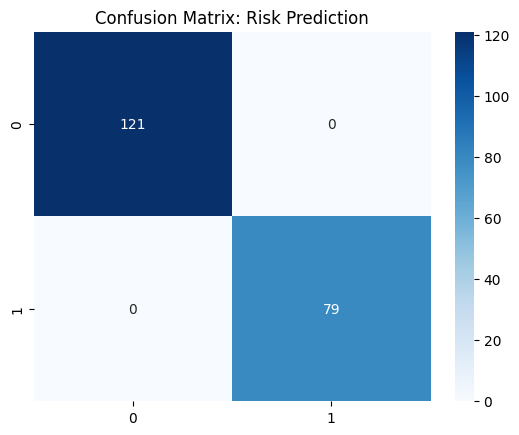

In [56]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Get probabilities
y_probs = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
print(f"ROC AUC Score: {roc_auc_score(y_test, y_probs)}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, grid_search.best_estimator_.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Risk Prediction')
plt.show()

Feature Importance Analysis

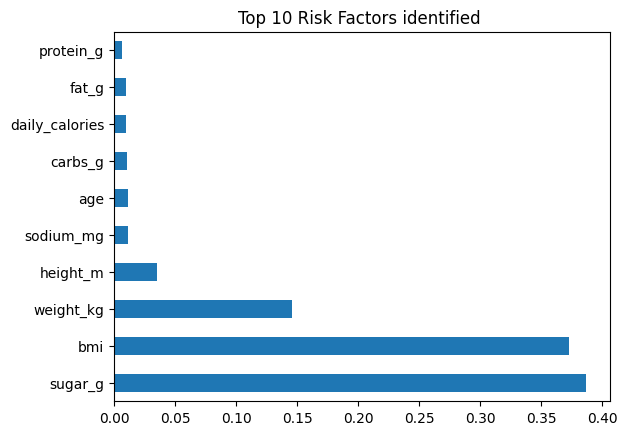

In [58]:
importances = grid_search.best_estimator_.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Risk Factors identified ')
plt.show()

Test with sample data

In [61]:
# 1. Create the sample patient (keep all columns initially)
sample_patient = pd.DataFrame([{
    'age': 45, 'gender': 1, 'height_m': 1.70, 'weight_kg': 85.0, 
    'bmi': 29.4, 'activity_level': 1, 'daily_calories': 2500, 
    'sugar_g': 80, 'sodium_mg': 4000, 'fat_g': 90, 
    'carbs_g': 300, 'protein_g': 70
}])

# 2. IMPORTANT: Remove columns that the VarianceThreshold dropped during training
# Use the same 'selector' object you used during the preprocessing step
sample_filtered = sample_patient[X.columns[selector.get_support()]]

# 3. Scale the filtered data
sample_scaled = scaler.transform(sample_filtered)

# 4. Predict
prediction = model.predict(sample_scaled)
print(f"Risk Prediction: {prediction}")

IndexError: Boolean index has wrong length: 12 instead of 10

In [60]:
# Check what the model expects
print("Features the model expects:", model.get_booster().feature_names)

# Check what your sample has
print("Features in your sample:", sample_patient.columns.tolist())

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- activity_level
- gender
